In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

# sklearn modules
from sklearn.model_selection import train_test_split   # not test_train_slit
from sklearn.preprocessing import StandardScaler       # not preprocessiung
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # spelling corrected
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier        # not DicisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# HOG feature extraction
from skimage.feature import hog   # not "sklearn.feature" or "hogi"


In [2]:
#load image and extract HOG features
data=[]
labels=[]
dataset_path="Bird Speciees Dataset"
categories= ["AMERICAN GOLDFINCH","BARN OWL","CARMINE BEE-EATER","DOWNY WOODPECKER","EMPEROR PENGUIN","FLAMINGO"]

for category in categories:
    path=os.path.join(dataset_path,category)
    label=categories.index(category) #AMERICAN GOLDFINCH=0,BARN OWL=1

    for img_name in os.listdir(path):
        img_path=os.path.join(path,img_name)

        img=cv2.imread(img_path)
        img=cv2.resize(img, (128,128))
        gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        features= hog(gray,
                      orientations=9,
                      pixels_per_cell=(8,8),
                      cells_per_block=(2,2),
                      block_norm='L2-Hys')
        data.append(features)
        labels.append(label)

x=np.array(data)  
y=np.array(labels) 

print("Dataset Shape",x.shape)
print("Labels Shape",y.shape)


Dataset Shape (811, 8100)
Labels Shape (811,)


In [3]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

print("training samples",x_train.shape)
print("testing samples",x_test.shape)

training samples (648, 8100)
testing samples (163, 8100)


In [4]:
#Model selection or model building

# 1.import algorithm
from sklearn.linear_model import LogisticRegression
# 2.object for class
# model 
lr=LogisticRegression()
#Model training
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
#Model testing---x_text data
result=lr.predict(x_test)
print(result)

[5 2 4 5 3 0 2 3 0 4 4 2 3 4 1 1 0 5 3 4 0 3 2 1 1 2 3 5 4 5 3 0 3 4 1 1 0
 2 5 4 2 3 5 3 1 0 4 4 4 1 0 1 4 1 2 2 0 5 3 2 3 2 1 5 0 1 5 4 3 5 2 4 4 0
 5 4 5 3 5 0 4 3 0 4 3 0 4 3 1 3 3 0 0 4 1 3 3 2 4 4 5 0 5 4 4 1 0 0 0 2 2
 0 4 4 2 2 4 4 5 0 2 3 4 4 0 4 1 4 1 5 3 2 0 0 2 4 1 3 0 4 2 4 0 1 0 4 3 5
 5 0 3 1 4 1 3 5 5 3 0 4 0 1 3]


In [6]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report



score=accuracy_score(y_test,result)
print("Accuracy Score for LR Model:",score)

#classification report
report=classification_report(y_test,result)
print("Classification Report :\n")
print(report)

Accuracy Score for LR Model: 0.6993865030674846
Classification Report :

              precision    recall  f1-score   support

           0       0.74      0.79      0.77        29
           1       0.68      0.58      0.62        26
           2       0.76      0.62      0.68        26
           3       0.72      0.75      0.74        28
           4       0.68      0.93      0.79        28
           5       0.59      0.50      0.54        26

    accuracy                           0.70       163
   macro avg       0.70      0.69      0.69       163
weighted avg       0.70      0.70      0.69       163



[[23  2  0  1  1  2]
 [ 2 15  2  4  1  2]
 [ 2  0 16  1  3  4]
 [ 2  2  1 21  1  1]
 [ 0  1  0  1 26  0]
 [ 2  2  2  1  6 13]]


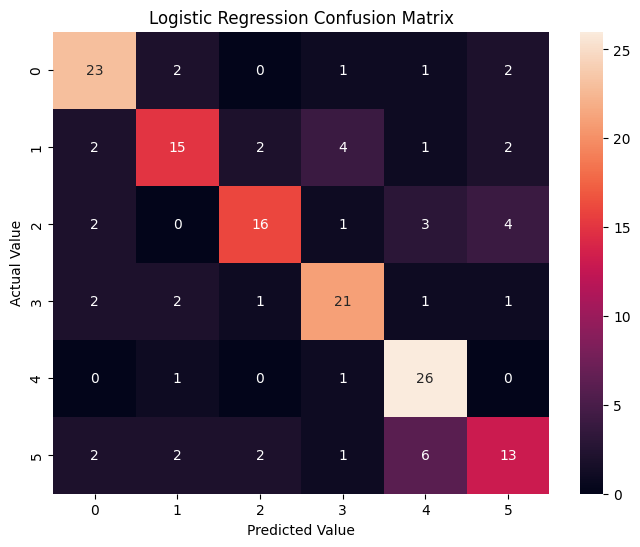

In [7]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,result)
print(cm)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Logistic Regression Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [8]:
# Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier
# model building
dt=DecisionTreeClassifier()
#Model training
dt.fit(x_train,y_train)

#Model testing---x_text data

result_dt=dt.predict(x_test)
print(result_dt)

[3 2 4 5 1 0 5 1 1 5 2 0 1 1 0 1 0 3 5 4 0 4 2 1 1 2 1 1 4 4 3 1 2 4 1 1 3
 0 5 2 2 0 2 1 1 5 4 1 2 5 5 1 2 0 2 0 5 3 3 2 3 2 3 3 2 4 1 4 0 0 1 4 4 5
 0 2 3 3 3 4 4 1 2 4 5 1 2 0 4 4 5 2 0 1 1 1 1 2 0 2 2 2 0 1 5 2 2 0 3 4 1
 2 2 4 2 2 4 2 4 1 0 5 4 2 2 4 1 3 1 2 4 2 2 0 0 4 2 5 4 5 2 3 0 0 0 4 1 5
 1 0 0 2 4 4 3 5 3 3 0 4 1 3 3]


Accuracy Score for DT Model: 0.3619631901840491
Classification Report :

              precision    recall  f1-score   support

           0       0.42      0.38      0.40        29
           1       0.30      0.38      0.34        26
           2       0.41      0.58      0.48        26
           3       0.30      0.21      0.25        28
           4       0.48      0.50      0.49        28
           5       0.17      0.12      0.14        26

    accuracy                           0.36       163
   macro avg       0.35      0.36      0.35       163
weighted avg       0.35      0.36      0.35       163

[[11  5  4  2  2  5]
 [ 3 10  5  3  4  1]
 [ 6  2 15  1  1  1]
 [ 3  9  2  6  3  5]
 [ 0  3  8  0 14  3]
 [ 3  4  3  8  5  3]]


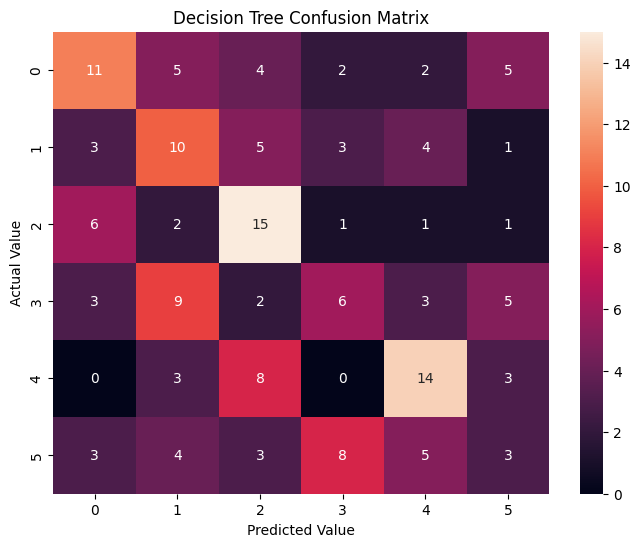

In [9]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_dt=accuracy_score(y_test,result_dt)
print("Accuracy Score for DT Model:",score_dt)

#classification report
report_dt=classification_report(y_test,result_dt)
print("Classification Report :\n")
print(report_dt)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt=confusion_matrix(y_test,result_dt)
print(cm_dt)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Decision Tree Confusion Matrix")

sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [10]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

# model building
rf=RandomForestClassifier()
#Model training
rf.fit(x_train,y_train)
#Model testing---x_text data
result_rf=rf.predict(x_test)
print(result_rf)

[3 2 4 5 3 5 2 3 0 5 3 2 5 0 2 1 0 5 3 4 5 1 2 1 4 2 3 1 4 5 1 0 5 4 1 0 0
 2 5 4 2 3 5 3 1 4 4 5 4 1 0 1 4 0 2 2 0 1 3 2 3 2 1 5 2 1 5 4 0 0 2 4 4 0
 5 4 1 3 1 0 4 3 0 4 3 1 4 5 5 1 3 0 0 5 3 1 1 2 1 4 5 0 2 4 4 1 2 0 0 2 3
 0 4 5 2 2 5 4 0 3 2 3 4 4 2 4 0 4 1 2 3 2 2 0 2 4 0 4 0 4 2 2 0 1 0 4 3 4
 5 0 3 1 4 3 3 0 5 1 0 4 0 1 3]


Accuracy Score for RF Model: 0.6257668711656442
Classification Report :

              precision    recall  f1-score   support

           0       0.65      0.69      0.67        29
           1       0.52      0.50      0.51        26
           2       0.75      0.81      0.78        26
           3       0.54      0.46      0.50        28
           4       0.73      0.86      0.79        28
           5       0.50      0.42      0.46        26

    accuracy                           0.63       163
   macro avg       0.61      0.62      0.62       163
weighted avg       0.62      0.63      0.62       163

[[20  2  2  1  2  2]
 [ 4 13  2  5  0  2]
 [ 0  1 21  0  2  2]
 [ 4  5  1 13  2  3]
 [ 0  0  0  2 24  2]
 [ 3  4  2  3  3 11]]


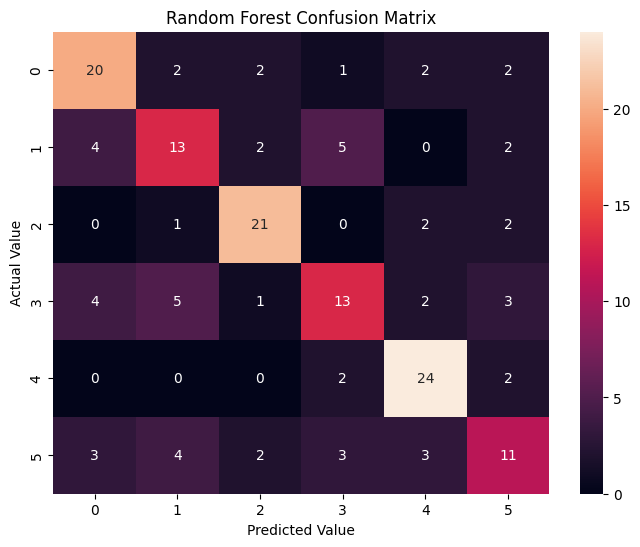

In [11]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_rf=accuracy_score(y_test,result_rf)
print("Accuracy Score for RF Model:",score_rf)

#classification report
report_rf=classification_report(y_test,result_rf)
print("Classification Report :\n")
print(report_rf)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf=confusion_matrix(y_test,result_rf)
print(cm_rf)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Random Forest Confusion Matrix")

sns.heatmap(cm_rf,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [12]:
#Support Vector machine
from sklearn.svm import SVC
# model building
svc=SVC(probability=True)
#Model training
svc.fit(x_train,y_train)
#Model testing---x_text data
result_svc=svc.predict(x_test)
print(result_svc)

[5 2 4 5 3 0 2 3 0 5 3 2 3 0 1 1 0 5 3 4 5 3 2 1 1 2 3 5 4 5 3 0 3 4 1 0 0
 2 5 4 2 3 5 3 3 0 4 5 4 3 0 1 4 1 2 2 0 5 3 2 3 2 1 5 2 1 5 4 3 0 2 4 4 0
 5 4 5 3 3 0 4 3 0 4 3 0 4 3 3 3 3 0 0 4 1 3 3 2 4 4 5 0 5 4 4 1 2 0 0 5 3
 0 4 5 2 2 4 2 1 0 2 3 4 2 0 4 1 4 1 5 3 2 5 0 2 4 1 3 0 4 2 2 0 1 0 4 3 5
 5 2 3 1 4 3 3 5 5 1 0 4 0 1 3]


Accuracy Score for RF Model: 0.7055214723926381
Classification Report :

              precision    recall  f1-score   support

           0       0.76      0.76      0.76        29
           1       0.68      0.50      0.58        26
           2       0.80      0.77      0.78        26
           3       0.60      0.75      0.67        28
           4       0.80      0.86      0.83        28
           5       0.60      0.58      0.59        26

    accuracy                           0.71       163
   macro avg       0.71      0.70      0.70       163
weighted avg       0.71      0.71      0.70       163

[[22  2  1  1  0  3]
 [ 3 13  2  6  1  1]
 [ 0  0 20  1  0  5]
 [ 2  3  1 21  1  0]
 [ 0  1  0  2 24  1]
 [ 2  0  1  4  4 15]]


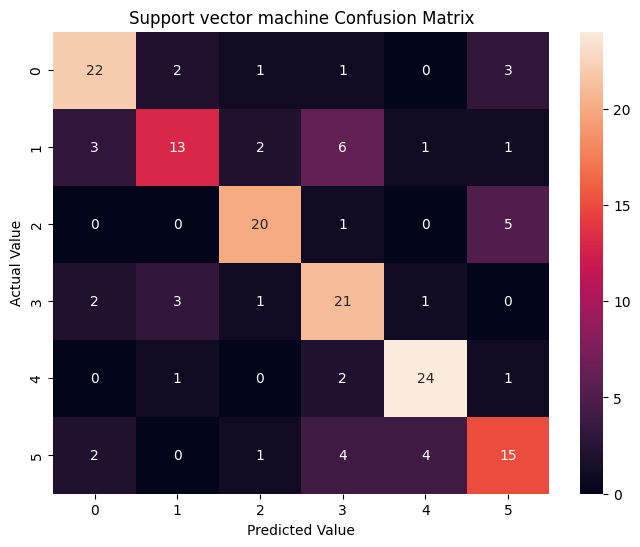

In [13]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_svc=accuracy_score(y_test,result_svc)
print("Accuracy Score for RF Model:",score_svc)

#classification report
report_svc=classification_report(y_test,result_svc)
print("Classification Report :\n")
print(report_svc)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svc=confusion_matrix(y_test,result_svc)
print(cm_svc)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Support vector machine Confusion Matrix")

sns.heatmap(cm_svc,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [14]:
import joblib
# ==========================
# Choose best model and save
# ==========================
# Save SVM model
joblib.dump(svc, 'svm_model_nlp.pkl')
joblib.dump(scaler,'scaler.pkl')
print("model saved succefully")

model saved succefully


Model loaded successfully!


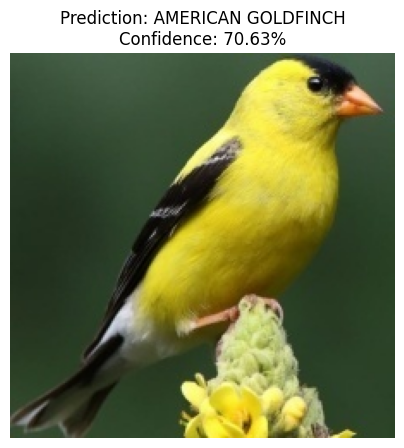

In [15]:
# ==========================
# Real-Time Prediction Code
# ==========================

import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from skimage.feature import hog

# ==========================
# Load Model & Scaler
# ==========================

model = joblib.load("svm_model_nlp.pkl")
scaler = joblib.load("scaler.pkl")

print("Model loaded successfully!")

# ==========================
# Class Labels (MUST match training order)
# ==========================

categories = [
    "AMERICAN GOLDFINCH",
    "BARN OWL",
    "CARMINE BEE-EATER",
    "DOWNY WOODPECKER",
    "EMPEROR PENGUIN",
    "FLAMINGO"
]

# ==========================
# Prediction Function
# ==========================

def predict_image(image_path):

    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print("Error: Image not found!")
        return

    # Resize (same as training)
    img_resized = cv2.resize(img, (128, 128))

    # Convert to grayscale
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Extract HOG features (same parameters)
    features = hog(gray,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   block_norm='L2-Hys')

    # Scale features
    features = scaler.transform([features])

    # Predict
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    
    # Get label
    if isinstance(prediction,str):
        label=prediction
    else:    
        label = categories[prediction]

    # Confidence
    confidence = np.max(probabilities) * 100

    # ==========================
    # Show Image with Prediction
    # ==========================

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

# ==========================
# Pass Your Image Path Here and test
# ==========================

image_path = "Bird Speciees Dataset/AMERICAN GOLDFINCH/002.jpg"

predict_image(image_path)